<a href="https://colab.research.google.com/github/Shreyapowar9961/Deep_Learning_sem6/blob/main/Assignment_6_%E2%80%93_(RNN_LSTM_or_Sequence_Model_%E2%80%93_typical_DL_lab).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Example: Time series data (replace with your dataset if provided)
data = pd.read_csv("/content/drive/MyDrive/DeepLearning/EXPERIMENTS/AirPassengers.csv")  # or your dataset
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
values = data.iloc[:,1].values.reshape(-1,1)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(values)

In [4]:
def create_dataset(data, time_step=10):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 10
X, y = create_dataset(scaled_data, time_step)

In [5]:
split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [6]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [7]:
model = Sequential()

model.add(LSTM(50, return_sequences=False, input_shape=(time_step,1)))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [9]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=16
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0434 - val_loss: 0.0947
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0138 - val_loss: 0.0240
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0079 - val_loss: 0.0176
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0083 - val_loss: 0.0189
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0059 - val_loss: 0.0237
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0060 - val_loss: 0.0245
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0057 - val_loss: 0.0206
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0051 - val_loss: 0.0177
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0054 - val_loss: 0.0178
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0050 - val_loss: 0.0181
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0050 - val_loss: 0.0184
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0047 - val_loss: 0.0180
E

In [10]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [11]:
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

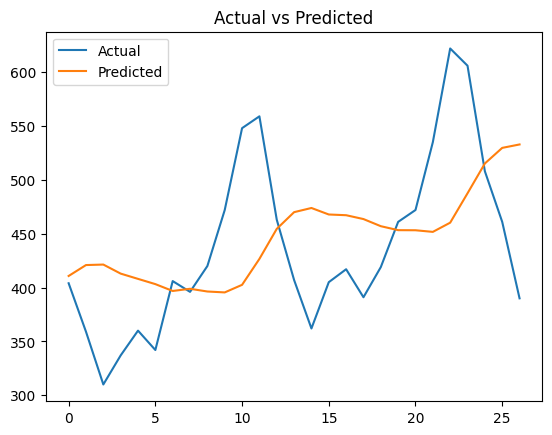

In [12]:
plt.plot(y_test_actual, label='Actual')
plt.plot(test_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

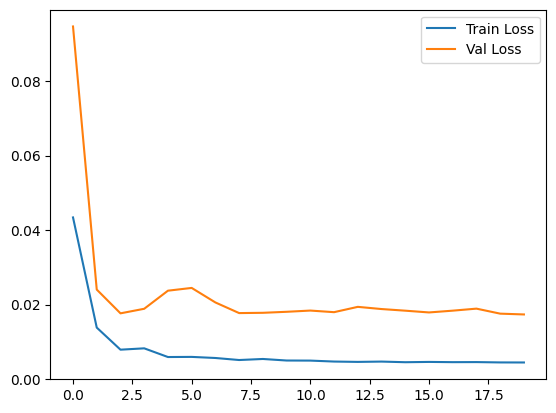

In [13]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [14]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [15]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
X_train = pad_sequences(X_train, maxlen=100)
X_test = pad_sequences(X_test, maxlen=100)

In [17]:
from tensorflow.keras.layers import Embedding

model2 = Sequential()

model2.add(Embedding(5000, 64, input_length=100))
model2.add(LSTM(64))
model2.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [18]:
model2.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

In [19]:
history2 = model2.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 66ms/step - accuracy: 0.7905 - loss: 0.4429 - val_accuracy: 0.8180 - val_loss: 0.4102
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.8743 - loss: 0.3039 - val_accuracy: 0.8280 - val_loss: 0.3844
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 63ms/step - accuracy: 0.8987 - loss: 0.2545 - val_accuracy: 0.8378 - val_loss: 0.4022
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.9200 - loss: 0.2038 - val_accuracy: 0.8420 - val_loss: 0.3989
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.9371 - loss: 0.1680 - val_accuracy: 0.8384 - val_loss: 0.4461


In [20]:
loss, acc = model2.evaluate(X_test, y_test)
print("Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8396 - loss: 0.4511
Accuracy: 0.8395599722862244


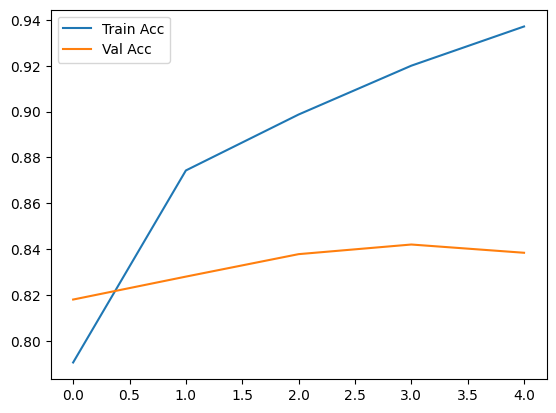

In [21]:
plt.plot(history2.history['accuracy'], label='Train Acc')
plt.plot(history2.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()